In [14]:
%matplotlib ipympl
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, display, Math
import pickle
import os

In [15]:

# ==========================
# Setup and Data Loading
# ==========================

# --- Results Directory and Output Setup ---
results_dir = "../../Results/Data/Complete_rho/"

Output_dir = "../../Results/Plot/Populations"
os.makedirs(Output_dir, exist_ok=True)

# --- Time Step and Trajectory String Formatting ---

dt = 0.01
N_traj = 10000
dt_str = f"{dt:.6f}".replace(".", "p")

# Load Quantum Jump (QJ) Data
fname_QJ = os.path.join(results_dir, f"result_mode_QJ_dt{dt_str}_Ntraj{N_traj}.npz")
data_QJ = np.load(fname_QJ)

# Load State Diffusion (SD) Data
fname_SD = os.path.join(results_dir, f"result_mode_SD_dt{dt_str}_Ntraj{N_traj}.npz")
data_SD = np.load(fname_SD)

print("Data extraction completed")



Data extraction completed


In [30]:
times = data_QJ['times']

total_jumps_QJ = data_QJ['total_jumps']
total_jumps_SD = data_SD['total_jumps']

# -----------------------------------------------
# Extract from rho_tot_all (3, 3, n_times, N_traj)
# -----------------------------------------------
rho_all_QJ = data_QJ['rho_tot_all']   # (3, 3, n_times, N_traj)
rho_all_SD = data_SD['rho_tot_all']

# Populations: diagonal of the density matrix
pop_00_QJ = np.real(rho_all_QJ[0, 0, :, :])  # (n_times, N_traj)
pop_11_QJ = np.real(rho_all_QJ[1, 1, :, :])
pop_22_QJ = np.real(rho_all_QJ[2, 2, :, :])
coh_01_QJ = rho_all_QJ[0, 1, :, :]           # Coherence (complex)
coh_12_QJ = rho_all_QJ[1, 2, :, :]

pop_00_SD = np.real(rho_all_SD[0, 0, :, :100])
pop_11_SD = np.real(rho_all_SD[1, 1, :, :100])
pop_22_SD = np.real(rho_all_SD[2, 2, :, :100])
coh_01_SD = rho_all_SD[0, 1, :, :100]
coh_12_SD = rho_all_SD[1, 2, :, :100]

# Averages over all trajectories
avg_pop_00_QJ = pop_00_QJ.mean(axis=1)
avg_pop_11_QJ = pop_11_QJ.mean(axis=1)
avg_pop_22_QJ = pop_22_QJ.mean(axis=1)
avg_pop_00_SD = pop_00_SD.mean(axis=1)
avg_pop_11_SD = pop_11_SD.mean(axis=1)
avg_pop_22_SD = pop_22_SD.mean(axis=1)
avg_coh_12_SD = coh_12_SD.mean(axis=1)

# Sample trajectories (first 50)
sample_traj_pop_22_QJ = pop_22_QJ[:, :50]
sample_traj_pop_22_SD = pop_22_SD[:, :50]

# -----------------------------------------------
# Extract baseline: rho_trace (3, 3, n_times)
# -----------------------------------------------
rho_trace_QJ = data_QJ['rho_trace']
pops_trace_00 = np.real(rho_trace_QJ[0, 0, :])
pops_trace_11 = np.real(rho_trace_QJ[1, 1, :])
pops_trace_22 = np.real(rho_trace_QJ[2, 2, :])

# -----------------------------------------------
# Extract Lindblad: rho_list_lindblad (n_times, 3, 3)
# -----------------------------------------------
rho_lind = data_QJ['rho_list_lindblad']
lindblad_00 = np.real(rho_lind[:, 0, 0])
lindblad_11 = np.real(rho_lind[:, 1, 1])
lindblad_22 = np.real(rho_lind[:, 2, 2])
lindblad_12 = rho_lind[:, 1, 2]

# -----------------------------------------------
# Extract isolated system: rho_traj_isolated (3, 3, n_times)
# -----------------------------------------------
rho_iso = data_QJ['rho_traj_isolated']
pop_traj_isolated_00 = np.real(rho_iso[0, 0, :])
pop_traj_isolated_11 = np.real(rho_iso[1, 1, :])
pop_traj_isolated_22 = np.real(rho_iso[2, 2, :])

In [21]:
total_jumps_QJ.shape 


(5000,)

In [17]:
# ===========================
# General Setup for Plotting
# ===========================

# --- Global Style Settings (Matplotlib rcParams) ---
plt.rcParams.update({
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 10,
    'figure.figsize': (8, 5),
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': ':',
    'figure.autolayout': True # plt.tight_layout()
})

# --- Automatic Figure Saving Function ---
def save_fig(fig, filename):
    """
    Saves the figure in both PNG or PDF
    """
    path_png = os.path.join(Output_dir, f"{filename}.png")
    # path_pdf = os.path.join(Output_dir, f"{filename}.pdf")  # save in pdf
    
    fig.savefig(path_png, dpi=300, bbox_inches='tight')
    # fig.savefig(path_pdf, bbox_inches='tight') # save in pdf
    print(f"Figure saved in: {Output_dir}/{filename}")

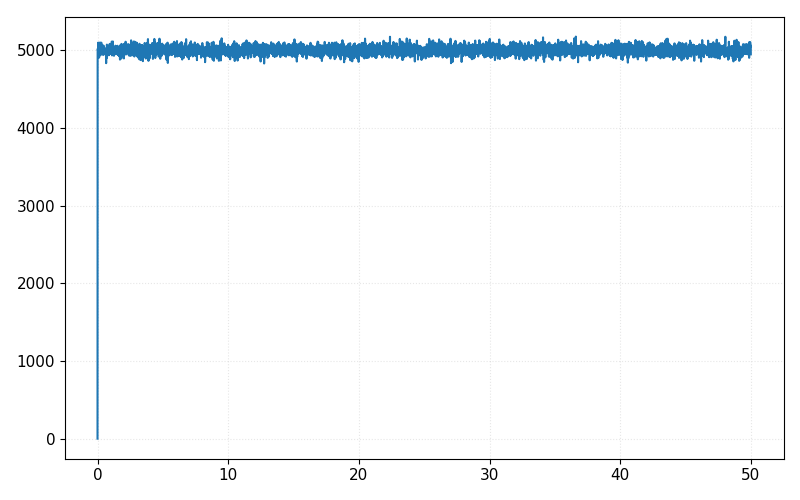

In [29]:
plt.close('all')
plt.plot(times, total_jumps_SD)
plt.show()

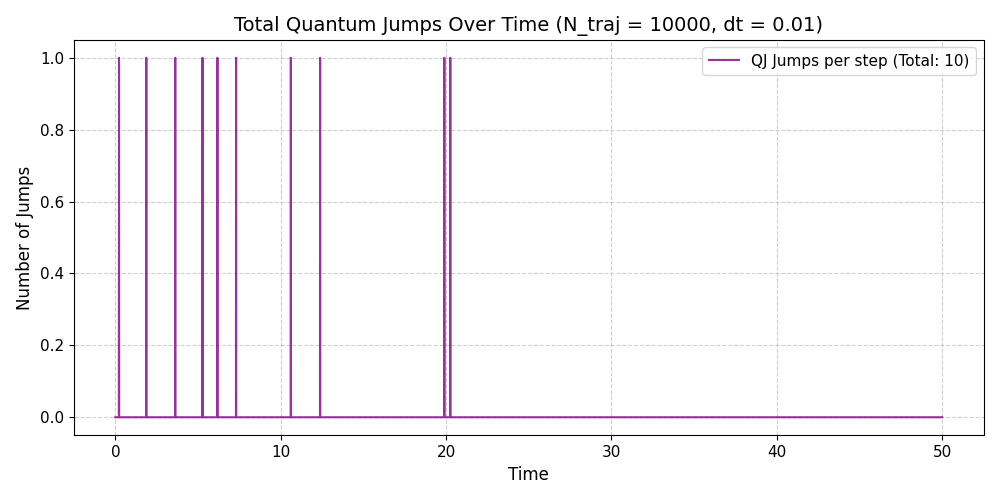

In [28]:
# ==========================================
# Plotting the Jump Counts (Quantum Jump)
# ==========================================
plt.close('all')
fig, ax = plt.subplots(figsize=(10, 5))

# Plotting the total number of jumps at each time step across all trajectories for QJ
ax.plot(times, total_jumps_QJ, color='purple', alpha=0.8, linewidth=1.5, 
        label=f'QJ Jumps per step (Total: {np.sum(total_jumps_QJ)})')

# Formatting the plot
ax.set_title(f"Total Quantum Jumps Over Time (N_traj = {N_traj}, dt = {dt})", fontsize=14)
ax.set_xlabel("Time", fontsize=12)
ax.set_ylabel("Number of Jumps", fontsize=12)
ax.grid(True, linestyle='--', alpha=0.6)
ax.legend(loc='upper right', fontsize=11)

plt.tight_layout()
plt.show()

Figure saved in: ../../Results/Plot/Populations/QJ_Comparison_3pop_dt0p010000_Ntraj10000


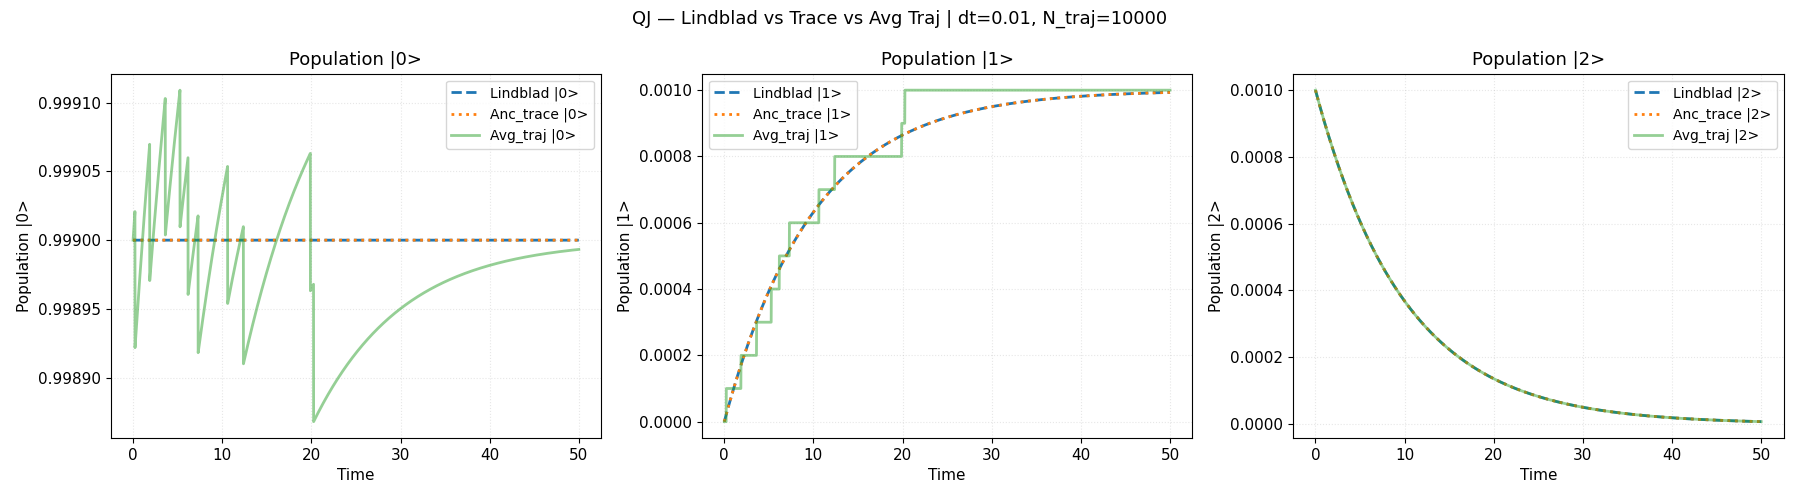

In [19]:
# ====================================
# Convergence Avg vs Trace vs Lindblad
# ====================================
plt.close('all')

mode = "QJ"  # "QJ" or "SD"

# Seleziona i dati in base al mode
avg_pop = {
    "QJ": (avg_pop_00_QJ, avg_pop_11_QJ, avg_pop_22_QJ),
    "SD": (avg_pop_00_SD, avg_pop_11_SD, avg_pop_22_SD),
}[mode]

populations = [
    {'lindblad': lindblad_00, 'trace': pops_trace_00, 'avg': avg_pop[0], 'label': '|0>'},
    {'lindblad': lindblad_11, 'trace': pops_trace_11, 'avg': avg_pop[1], 'label': '|1>'},
    {'lindblad': lindblad_22, 'trace': pops_trace_22, 'avg': avg_pop[2], 'label': '|2>'},
]

fig01, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)

for ax, pop in zip(axes, populations):
    lbl = pop['label']
    ax.plot(times, pop['lindblad'], label=f'Lindblad {lbl}', linewidth=2, linestyle='--')
    ax.plot(times, pop['trace'],    label=f'Anc_trace {lbl}', linewidth=2, linestyle=':')
    ax.plot(times, pop['avg'],      label=f'Avg_traj {lbl}',  linewidth=2, alpha=0.5)
    ax.set_title(f'Population {lbl}')
    ax.set_xlabel('Time')
    ax.set_ylabel(f'Population {lbl}')
    ax.legend()

fig01.suptitle(f'{mode} — Lindblad vs Trace vs Avg Traj | dt={dt}, N_traj={N_traj}', fontsize=13)

filename_01 = f'{mode}_Comparison_3pop_dt{dt_str}_Ntraj{N_traj}'
save_fig(fig01, filename_01)
plt.show()

In [ ]:
# ================================================
# Comparison trajectories Collisional vs Isolated
# ================================================

plt.close('all')

sample_idx = 1

fig02, ax = plt.subplots(figsize=(10,5))

ax.plot(times, sample_traj_pop_22_SD[:,sample_idx], label='Single Traj', linewidth=2)
ax.plot(times, pop_traj_isolated_22, label='Traj Isolated', linewidth=2, linestyle=':')

ax.set_title(r'Comparison trajectories Collisional vs Isolated')
ax.set_xlabel('Time')
ax.set_ylabel(f'Population site 2 ')
ax.legend()

# Automatically save the figure (PNG + PDF)
filename_02 = f'SD Comparison Collisional vs Isolated - dt={dt} & N_traj={N_traj}'
#save_fig(fig02, filename_02)

plt.show()


In [ ]:
# ===================================================
# Comparison Single Trajectory vs Average vs Lindblad
# ===================================================

plt.close('all')

fig03, ax = plt.subplots(figsize=(10, 5))

for i in range(sample_traj_pop_11_SD.shape[1]):
    ax.plot(times, sample_traj_pop_11_SD[:, i], color='gray', alpha=0.15, linewidth=0.5, 
             label='Single Traj' if i==0 else "")

ax.plot(times, lindblad_11, label=r'Lindblad', linewidth=2, linestyle='--')
ax.plot(times, avg_pop_11_SD, label=r'Avg_traj', linewidth=2, color='orange',  alpha=0.5)

ax.set_title(f'Comparison Many Trajectories vs Average - dt={dt} & N_traj={N_traj}')
ax.set_xlabel('Time')
ax.set_ylabel(f'Population site 1 ') # change site
ax.legend()

# Automatically save the figure (PNG + PDF)
filename_03 = 'SD Comparison Many Trajectories vs Average'
# save_fig(fig03, filename_03)
plt.show()

In [ ]:
plt.close('all')

fig04, ax = plt.subplots(figsize=(10, 5))

# -----------
# Populations
# -----------
#ax.plot(times, avg_pop_11_SD, label=r'pop 1')

#ax.plot(times, lindblad_11, label=r'pop 1 Lindblad', linewidth=2, linestyle='--')

# ---------------
# Real Coherences
# ---------------
#ax.plot(times, np.real(avg_coh_01_SD), label=r'cohe 1')

#ax.plot(times, np.real(lindblad_01), label=r'cohe 1 Lindblad', linewidth=2, linestyle='--')

# --------------------
# Imaginary Coherences
# --------------------
ax.plot(times, np.imag(avg_coh_01_SD), label=r'cohe 1')

ax.plot(times, np.imag(lindblad_01), label=r'cohe 1 Lindblad', linewidth=2, linestyle='--')

ax.set_title(f'Comparison Lindblad vs Average, Pop, Real and Imag Cohe - dt={dt} & N_traj={N_traj} ')
ax.set_xlabel('Time')
ax.set_ylabel('Value')
ax.legend()

plt.show()